In [ ]:
import pandas as pd
import numpy as np
from statsmodels.tsa.api import VAR
from scipy.linalg import norm
from sklearn.preprocessing import StandardScaler
import seaborn as sns
import matplotlib.pyplot as plt


class VARClientSimilarityPipeline:
    def __init__(self, maxlags=1, standardize=True, min_samples=10):
        """
        Parameters:
        - maxlags: number of lags to use in the VAR model
        - standardize: whether to z-score each time series per client
        - min_samples: minimum samples per window to fit VAR
        """
        self.maxlags = maxlags
        self.standardize = standardize
        self.min_samples = min_samples
        self.coeff_matrices = {}
        self.similarity_matrix = None

    def _preprocess(self, df):
        """Optional: standardize time series for each client"""
        if self.standardize:
            scaler = StandardScaler()
            df[['p1', 'p2', 'p3']] = scaler.fit_transform(df[['p1', 'p2', 'p3']])
        return df

    def _fit_var_model(self, ts):
        """Fit VAR model and return the coefficient matrix (A1)"""
        model = VAR(ts)
        result = model.fit(maxlags=self.maxlags)
        return result.coefs[0]  # shape: (n_vars, n_vars)

    def fit(self, data_clients):
        """
        Fits a VAR model to each client's data and stores coefficient matrices.

        Parameters:
        - data_clients: dict of client_name -> DataFrame with columns ['label', 'p1', 'p2', 'p3']
        """
        self.coeff_matrices = {}

        for client, df in data_clients.items():
            df = self._preprocess(df)
            try:
                coeff = self._fit_var_model(df[['p1', 'p2', 'p3']])
                self.coeff_matrices[client] = coeff
            except Exception as e:
                print(f"Failed to fit VAR for client {client}: {e}")

    def compute_similarity(self):
        """Computes Frobenius norm-based similarity matrix between client VAR coefficients."""
        clients = list(self.coeff_matrices.keys())
        n = len(clients)
        sim_matrix = np.zeros((n, n))

        for i in range(n):
            for j in range(n):
                A = self.coeff_matrices[clients[i]]
                B = self.coeff_matrices[clients[j]]
                diff = A - B
                sim = np.exp(-norm(diff, ord='fro'))  # similarity ∈ (0,1]
                sim_matrix[i, j] = sim

        self.similarity_matrix = pd.DataFrame(sim_matrix, index=clients, columns=clients)
        return self.similarity_matrix

    def plot_similarity_matrix(self, title="Client Similarity (Frobenius-based)"):
        """Visualize the similarity matrix as a heatmap"""
        if self.similarity_matrix is None:
            raise ValueError("Run compute_similarity() first.")
        sns.heatmap(self.similarity_matrix, annot=True, cmap='viridis', vmin=0, vmax=1)
        plt.title(title)
        plt.show()

    def compute_similarity_over_time(self, data_clients):
        """Optional: compute similarity matrices per label (e.g. month)"""
        similarity_over_time = []
        labels = sorted(set.union(*[set(df['label'].unique()) for df in data_clients.values()]))

        for label in labels:
            coeffs = {}
            for client, df in data_clients.items():
                window = df[df['label'] == label]
                if len(window) < self.min_samples:
                    continue
                try:
                    window = self._preprocess(window)
                    coeff = self._fit_var_model(window[['p1', 'p2', 'p3']])
                    coeffs[client] = coeff
                except:
                    continue

            if len(coeffs) < 2:
                continue

            clis = list(coeffs.keys())
            for i in range(len(clis)):
                for j in range(i + 1, len(clis)):
                    A = coeffs[clis[i]]
                    B = coeffs[clis[j]]
                    sim = np.exp(-norm(A - B, ord='fro'))
                    similarity_over_time.append({
                        'label': label,
                        'client_i': clis[i],
                        'client_j': clis[j],
                        'similarity': sim
                    })

        return pd.DataFrame(similarity_over_time)

pipeline = VARClientSimilarityPipeline(maxlags=1, standardize=True)
pipeline.fit(data_clients)
sim_df = pipeline.compute_similarity()
pipeline.plot_similarity_matrix()

In [4]:
import pandas as pd
import numpy as np
from fastdtw import fastdtw
from scipy.spatial.distance import euclidean, cosine
from tsfresh.feature_extraction import extract_features
from tsfresh.utilities.dataframe_functions import impute
from itertools import combinations
import matplotlib.pyplot as plt
import seaborn as sns
import glob
import os

# ========== STEP 1: DTW DISTANCE BETWEEN EACH PAIR OF CLIENTS ==========

def compute_multivariate_dtw_distance(df1, df2):
    ts1 = df1.to_numpy()  # shape: (T, D)
    ts2 = df2.to_numpy()

    min_len = min(len(ts1), len(ts2))
    ts1 = ts1[:min_len]
    ts2 = ts2[:min_len]

    dist, _ = fastdtw(ts1, ts2, dist=euclidean)
    return dist

# ========== STEP 2: FEATURE-BASED SIMILARITY ==========

def reshape_for_tsfresh(df, client_id):
    """
    Prepare DataFrame for tsfresh feature extraction:
    Columns: ['id', 'time', 'value', 'kind']
    """
    long_df = pd.DataFrame()
    for i, col in enumerate(df.columns):
        temp = pd.DataFrame({
            'id': f'{client_id}_{col}',
            'time': np.arange(len(df)),
            'value': df[col].values,
            'kind': col
        })
        long_df = pd.concat([long_df, temp])
    return long_df

In [5]:
exp_id = 'EXPERIMENT_INCOME'
dir_id = 'income_base'

folders_experiment = [f for f in glob.glob(os.path.join(f'results/{dir_id}', f'*{exp_id}*')) if os.path.isdir(f)]
# folders_experiment = [f.replace('___0', '').replace('results/density_base\\', '') for f in folders_experiment]

# ids_exp = folders_experiment[10].replace(f'results/{dir_id}\\', '').split('__')
# exp_path = 'datasets/leaks/Graeme/' + ids_exp[0] + '__' + ids_exp[1][:14] + '/'

# case = 'A_62_LL_LM__LL_LH_LM_LL_LL'
case = 'D_2_LL_LH__LH_LM_LL_LL_LL'
# case = 'C_65_LL_LH__LH_LL_LL_LL_LM'
exp_path = f'datasets/leaks/Graeme/{case}/'

features_map = {}
data_clients = {}

tgt_feat = 'p2'

for client in ['A', 'B', 'C', 'D', 'E']:
    aux_data = pd.read_csv(exp_path + f'Client{client}_Baseline.csv')
    features_map[client] = {k : v for k, v in zip(['v1', 'v2', 'p1', 'p2', 'p3'], aux_data.columns.tolist()[1:])}
    aux_data['timestamp'] = pd.to_datetime(aux_data['timestamp'], unit='s')
    years = aux_data['timestamp'].dt.year
    months = aux_data['timestamp'].dt.month

    # Compute base year from the minimum timestamp
    base_year = aux_data['timestamp'].min().year

    # Continuous month index
    aux_data['label'] = (years - base_year) * 12 + (months - 1)
    # aux_data.drop(columns = 'timestamp', inplace = True)
    aux_data.columns = ['timestamp', 'v1', 'v2', 'p1', 'p2', 'p3', 'label']
    # aux_data = aux_data[['timestamp', 'label','v1', 'v2',  'p1', 'p2', 'p3']]
    aux_data = aux_data[['label', 'p1', 'p2', 'p3']]
    aux_data = aux_data[['label', tgt_feat]]

    data_clients[client] = aux_data

# Assume data_clients is already loaded as described
# Each data_clients[client] is a DataFrame with 5 time series columns

clients = list(data_clients.keys())
num_clients = len(clients)

len(folders_experiment)

0

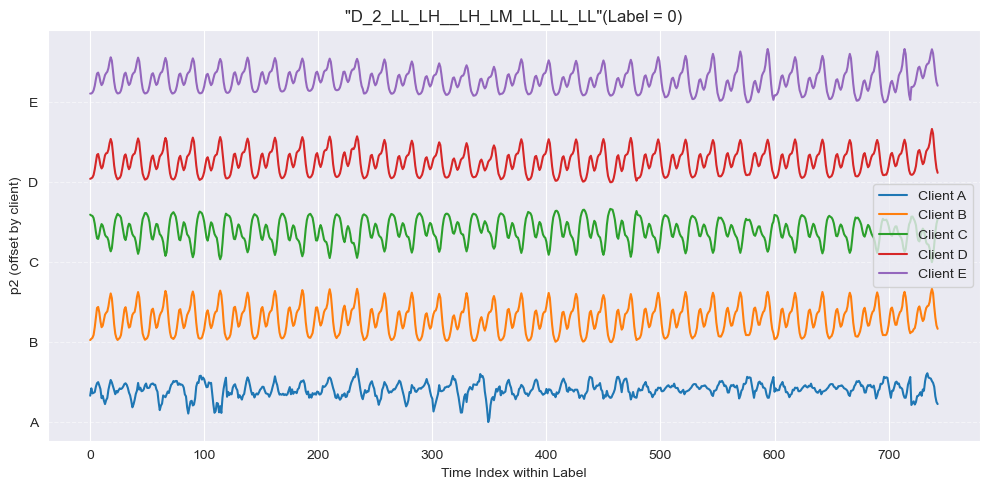

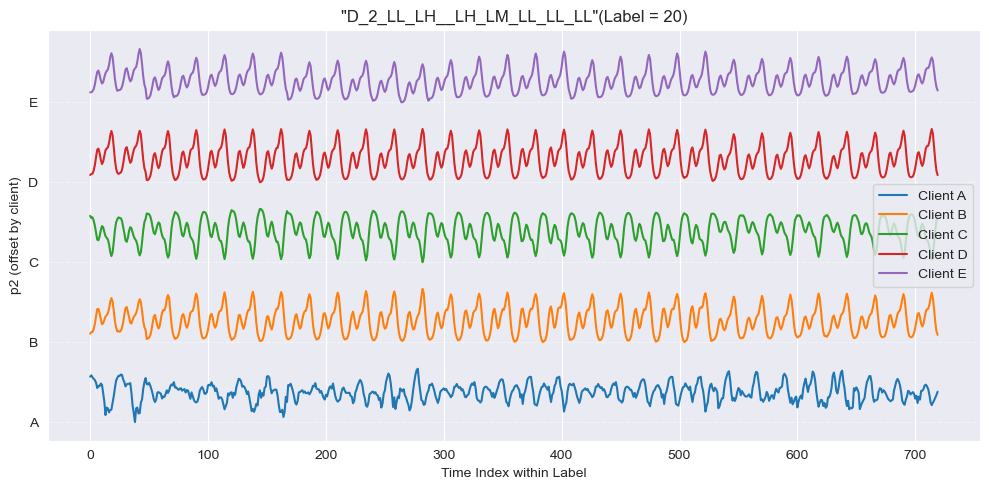

In [6]:
import matplotlib.pyplot as plt

import matplotlib.pyplot as plt
import numpy as np

import matplotlib.pyplot as plt
import numpy as np

def plot_variable_by_labels(data_clients, variable, labels, spacing=1.5):
    """
    Plot min-max normalized variable over time for each label, with vertical spacing per client.

    Parameters:
    - data_clients: dict of DataFrames (one per client)
    - variable: str, name of the variable to plot (e.g., 'v1')
    - labels: list of int, month indices to include
    - spacing: float, vertical space between clients
    """
    client_list = sorted(data_clients.keys())

    for label in labels:
        plt.figure(figsize=(10, 5))
        for i, client in enumerate(client_list):
            df = data_clients[client]
            df_label = df[df['label'] == label]
            if df_label.empty:
                continue

            values = df_label[variable].values
            if len(values) == 0:
                continue

            # Min-max normalize
            min_val = np.min(values)
            max_val = np.max(values)
            norm_values = (values - min_val) / (max_val - min_val) if max_val > min_val else np.zeros_like(values)

            # Apply vertical offset
            offset = i * spacing
            offset_values = norm_values + offset

            plt.plot(
                range(len(offset_values)),
                offset_values,
                label=f'Client {client}',
                # marker='o'
            )

        plt.title(f'"{case}"(Label = {label})')
        plt.xlabel('Time Index within Label')
        plt.ylabel(f'{variable} (offset by client)')
        plt.yticks(
            [i * spacing for i in range(len(client_list))],
            client_list
        )
        plt.grid(True, axis='y', linestyle='--', alpha=0.5)
        plt.legend()
        plt.tight_layout()
        plt.show()


plot_variable_by_labels(data_clients, variable='p2', labels=[0, 20])

C:\Users\arthu\anaconda3\envs\TsLeaks\lib\site-packages\tslearn\bases\bases.py:15: UserWarning: h5py not installed, hdf5 features will not be supported.
Install h5py to use hdf5 features: http://docs.h5py.org/
  warn(h5py_msg)


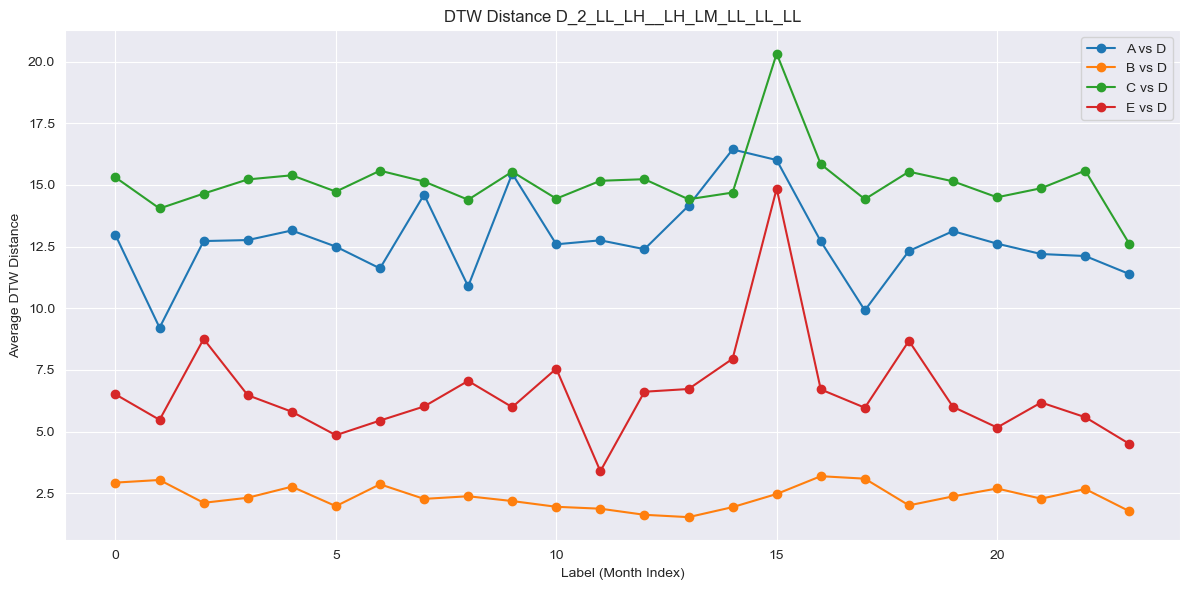

In [7]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from tslearn.metrics import dtw

target_client = case[0]
clients = list(data_clients.keys())

# Step 1: Gather all unique labels
all_labels = sorted(set(label for df in data_clients.values() for label in df['label'].unique()))

# Step 2: Initialize result storage
dtw_results = {client: [] for client in clients if client != target_client}
dtw_results['label'] = []

final_state_target = data_clients[target_client][data_clients[target_client]['label'] == 22].drop(columns='label')
scaler = StandardScaler()
final_state_target= scaler.fit_transform(final_state_target)

# Step 3: Loop through all labels
for label in all_labels:
    # 3.1: Extract data for the current label
    label_data = {
        client: df[df['label'] == label].drop(columns='label')
        for client, df in data_clients.items()
        if label in df['label'].values
    }

    if target_client not in label_data or any(len(label_data[c]) == 0 for c in label_data):
        continue  # skip if any client missing data for this label

    # 3.2: Scale time series
    label_data_scaled = {}
    for client, df in label_data.items():
        scaler = StandardScaler()
        label_data_scaled[client] = scaler.fit_transform(df)

    # 3.3: Compute DTW distances for this label
    dtw_results['label'].append(label)
    for client in clients:
        if client == target_client:
            continue
        dist_sum = 0
        for col in range(label_data_scaled[client].shape[1]):
            series_target = label_data_scaled[target_client][:, col] #final_state_target[:, col]#
            series_other = label_data_scaled[client][:, col]
            dist_sum += dtw(series_target, series_other)
        dtw_results[client].append(dist_sum)  # average over time series

# Step 4: Convert to DataFrame
df_dtw = pd.DataFrame(dtw_results)

# Step 5: Plot
plt.figure(figsize=(12, 6))
for client in df_dtw.columns:
    if client != 'label':
        plt.plot(df_dtw['label'], df_dtw[client], label=f'{client} vs {target_client}', marker='o')

plt.xlabel('Label (Month Index)')
plt.ylabel('Average DTW Distance')
plt.title(f'DTW Distance {case}')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

In [8]:
df_nodes = pd.read_csv("Graeme_node_distances.csv")
df_edges = pd.read_csv("Graeme_edge_distances.csv")

df_nodes_a = df_nodes.copy()
df_nodes_b = df_nodes.copy()
df_nodes_b.columns = ['client_2', 'client_1', 'to_edge', 'from_edge', 'distance']
df_nodes_b = df_nodes_b[['client_1', 'client_2', 'from_edge', 'to_edge', 'distance']]

df_nodes = pd.concat([df_nodes_a, df_nodes_b])

df_edges_a = df_edges.copy()
df_edges_b = df_edges.copy()
df_edges_b.columns = ['client_2', 'client_1', 'to_edge', 'from_edge', 'distance']
df_edges_b = df_edges_b[['client_1', 'client_2', 'from_edge', 'to_edge', 'distance']]

df_edges = pd.concat([df_edges_a, df_edges_b])

In [9]:
df_edges.head()

,client_1,client_2,from_edge,to_edge,distance
0,A,B,102,157,7293.0
1,A,B,102,135,943.0
2,A,B,102,165,7017.0
3,A,B,100,157,8894.0
4,A,B,100,135,2544.0


In [10]:
aux_dist = []
for c, s in features_map.items():
    aux_dist.append({'client': c, 'sensor_id': int(s[tgt_feat])})

df_dist = pd.DataFrame(aux_dist)
df_dist

,client,sensor_id
0,A,100
1,B,135
2,C,119
3,D,96
4,E,11


In [11]:
df_edges_agg = df_edges.groupby(['client_1', 'client_2']).agg({'distance' : 'mean'}).reset_index()
df_edges_agg_D = df_edges_agg[df_edges_agg['client_1'] == 'D'].copy()
df_edges_agg_D['dist_norm'] = df_edges_agg_D['distance'] / df_edges_agg_D['distance'].sum()
df_edges_agg_D.sort_values(by='client_2')

,client_1,client_2,distance,dist_norm
12,D,A,5800.666667,0.267155
13,D,B,7846.222222,0.361364
14,D,C,3470.666667,0.159844
15,D,E,4595.222222,0.211637


In [12]:
tgt_sensor = df_dist[df_dist['client'] == target_client]['sensor_id'].values[0]

sensors_tgt = df_edges[(df_edges['client_1'] == target_client) & (df_edges['from_edge'] == tgt_sensor)]
sensors_tgt = sensors_tgt[sensors_tgt['to_edge'].isin(df_dist['sensor_id'])].copy()
sensors_tgt['dist_norm'] = sensors_tgt['distance'] / sensors_tgt['distance'].sum()
sensors_tgt.sort_values(by='client_2')

,client_1,client_2,from_edge,to_edge,distance,dist_norm
22,D,A,96,100,4300.0,0.285544
49,D,B,96,135,2626.0,0.174381
67,D,C,96,119,2358.0,0.156584
85,D,E,96,11,5775.0,0.383492


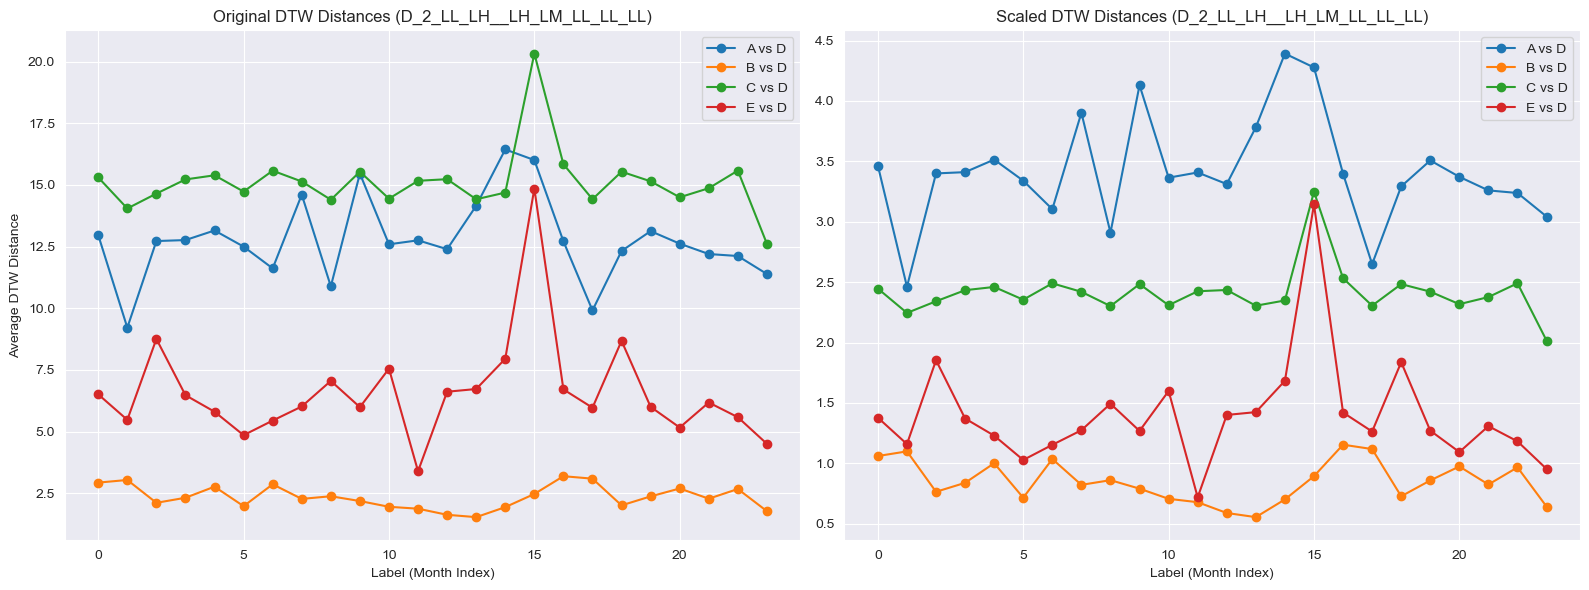

In [14]:
# Step 1: Create a dictionary of dist_norm values where client_1 == 'D'
dist_norm_map = df_edges_agg_D[df_edges_agg_D['client_1'] == 'D'].set_index('client_2')['dist_norm'].to_dict()

# Step 2: Copy the df_dtw so we don't modify it directly
df_dtw_scaled = df_dtw.copy()

# Step 3: Multiply each relevant column by its corresponding dist_norm
for client_col in ['A', 'B', 'C', 'E']:
    if client_col in dist_norm_map:
        df_dtw_scaled[client_col] = dist_norm_map[client_col] * df_dtw_scaled[client_col]
    else:
        print(f"Warning: No dist_norm found for client '{client_col}' — column will be left unchanged.")

import matplotlib.pyplot as plt

# Set up side-by-side subplots
fig, axes = plt.subplots(1, 2, figsize=(16, 6), sharey=False)

# Plot 1: Original DTW distances
for client in df_dtw.columns:
    if client != 'label':
        axes[0].plot(df_dtw['label'], df_dtw[client], label=f'{client} vs {target_client}', marker='o')

axes[0].set_title(f'Original DTW Distances ({case})')
axes[0].set_xlabel('Label (Month Index)')
axes[0].set_ylabel('Average DTW Distance')
axes[0].legend()
axes[0].grid(True)

# Plot 2: Scaled DTW distances
for client in df_dtw_scaled.columns:
    if client != 'label':
        axes[1].plot(df_dtw_scaled['label'], df_dtw_scaled[client], label=f'{client} vs {target_client}', marker='o')

axes[1].set_title(f'Scaled DTW Distances ({case})')
axes[1].set_xlabel('Label (Month Index)')
axes[1].legend()
axes[1].grid(True)

# Layout
plt.tight_layout()

In [15]:
dist_norm_map

{'A': 0.26715451730931605,
 'B': 0.3613642760279405,
 'C': 0.15984443364122505,
 'E': 0.2116367730215183}

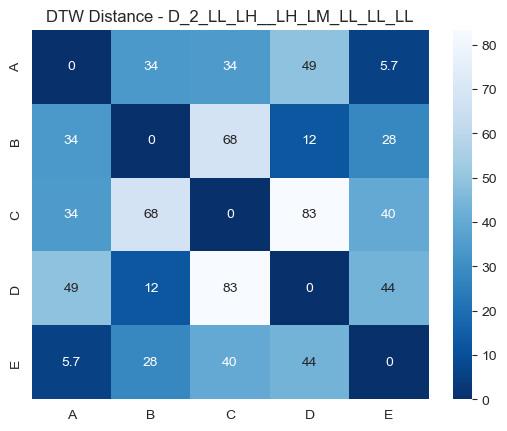

In [16]:
label = 22

dtw_distances = pd.DataFrame(index=clients, columns=clients, dtype=float)

for c1, c2 in combinations(clients, 2):
    client1_label = data_clients[c1][data_clients[c1]['label'] == label].drop(columns = 'label')
    client2_label = data_clients[c2][data_clients[c2]['label'] == label].drop(columns = 'label')

    # client1_label = data_clients[c1].drop(columns = 'label')
    # client2_label = data_clients[c2].drop(columns = 'label')

    dist = compute_multivariate_dtw_distance(client1_label.iloc[:, -1:], client2_label.iloc[:, -1:])
    dtw_distances.loc[c1, c2] = dist
    dtw_distances.loc[c2, c1] = dist

np.fill_diagonal(dtw_distances.values, 0)

# Optional visualization
sns.heatmap(dtw_distances.astype(float), annot=True, cmap="Blues_r")
plt.title(f"DTW Distance - {case}")
plt.show()

In [20]:
from itertools import product

fc_dict = {
                "time_reversal_asymmetry_statistic": [
                    {"lag": lag} for lag in range(1, 4)
                ],
                "c3": [{"lag": lag} for lag in range(1, 4)],
                "large_standard_deviation": [{"r": r * 0.05} for r in range(1, 5)],
                "autocorrelation": [{"lag": lag} for lag in range(1, 7)],
                "agg_autocorrelation": [
                    {"f_agg": s, "maxlag": 40} for s in ["mean", "median", "var"]
                ],
                "partial_autocorrelation": [{"lag": lag} for lag in range(1, 7)],
                "number_cwt_peaks": [{"n": n} for n in [1, 5]],
                "number_peaks": [{"n": n} for n in [1, 3, 5, 10, 50]],
                "binned_entropy": [{"max_bins": max_bins} for max_bins in [10]],
                "cwt_coefficients": [
                    {"widths": width, "coeff": coeff, "w": w}
                    for width in [(2, 5, 10, 20)]
                    for coeff in range(15)
                    for w in (2, 5, 10, 20)
                ],
                "spkt_welch_density": [{"coeff": coeff} for coeff in [2, 5, 8]],
                "ar_coefficient": [
                    {"coeff": coeff, "k": k} for coeff in range(10 + 1) for k in [10]
                ],
                "fft_coefficient": [
                    {"coeff": k, "attr": a}
                    for a, k in product(["real", "imag", "abs", "angle"], range(10))
                ],
                "fft_aggregated": [
                    {"aggtype": s} for s in ["centroid", "variance", "skew", "kurtosis"]
                ],
                "approximate_entropy": [
                    {"m": 2, "r": r} for r in [0.1, 0.3, 0.5, 0.7, 0.9]
                ],
                # "friedrich_coefficients": (
                #     lambda m: [
                #         {"coeff": coeff, "m": m, "r": 30} for coeff in range(m + 1)
                #     ]
                # )(3),
                # "max_langevin_fixed_point": [{"m": 3, "r": 30}],
                "linear_trend": [
                    {"attr": "pvalue"},
                    {"attr": "rvalue"},
                    {"attr": "intercept"},
                    {"attr": "slope"},
                    {"attr": "stderr"},
                ],
                # "augmented_dickey_fuller": [
                #     {"attr": "teststat"},
                #     {"attr": "pvalue"},
                #     {"attr": "usedlag"},
                # ],
                "energy_ratio_by_chunks": [
                    {"num_segments": 5, "segment_focus": i} for i in range(5)
                ],
                "lempel_ziv_complexity": [{"bins": x} for x in [2, 3, 5, 10, 100]],
                "fourier_entropy": [{"bins": x} for x in [2, 3, 5, 10, 100]],
                "permutation_entropy": [
                    {"tau": 1, "dimension": x} for x in [3, 4, 5, 6, 7]
                ],
            }

best_keys = [
    "autocorrelation",
    "partial_autocorrelation",
    "agg_autocorrelation",
    "fft_coefficient",
    "fft_aggregated",
    "spkt_welch_density",
    "fourier_entropy",
    "approximate_entropy",
    "permutation_entropy",
    "lempel_ziv_complexity",
    "linear_trend",
]

features_dict = { k : fc_dict[k] for k in best_keys }

In [21]:
# Combine all client data
all_series = pd.DataFrame()
for label in data_clients['A']['label'].unique().tolist():
    for client in clients:
        client_label = data_clients[client][data_clients[client]['label'] == label]

        for i, col in enumerate(client_label.columns[1:]):
            features = extract_features(client_label[['label', col]], default_fc_parameters = features_dict, column_id = 'label', column_value = col, disable_progressbar=True)

            # new_cols = [c.split('__')[1] for c in features.columns]
            # features.columns = new_cols
            features['client'] = client
            features['feat'] = i
            all_series = pd.concat([all_series, features], axis = 0)

print(all_series.shape)

(120, 89)


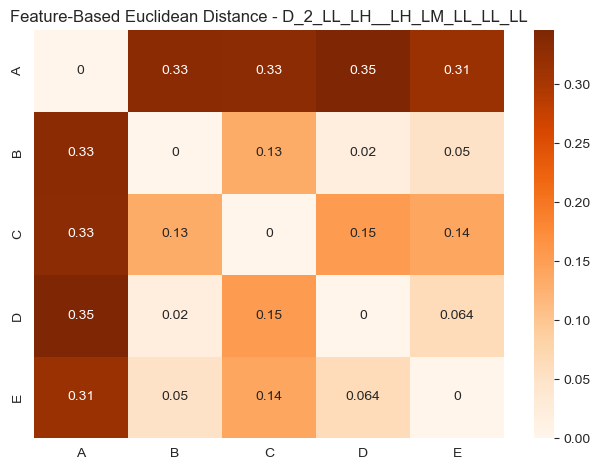

In [23]:
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics.pairwise import euclidean_distances, cosine_distances
from itertools import combinations
import seaborn as sns
import matplotlib.pyplot as plt

for feat in all_series['feat'].unique():
    # Step 1: Filter feature block
    client_feat_series = all_series[(all_series['feat'] == feat)].drop(columns='feat')

    # Step 2: Get raw feature matrix and min-max scale it
    feature_matrix = client_feat_series.drop(columns='client').values
    scaler = MinMaxScaler()
    scaled_features = scaler.fit_transform(feature_matrix)

    # Step 3: Map each scaled row back to its client
    client_feat_series_scaled = pd.DataFrame(
        scaled_features,
        columns=client_feat_series.columns.drop('client'),
        index=client_feat_series.index
    )
    client_feat_series_scaled['client'] = client_feat_series['client'].values

    # Step 4: Create dictionary of client vectors
    client_vectors = {
        client: client_feat_series_scaled[client_feat_series_scaled['client'] == client].drop(columns='client').values
        for client in clients
    }

    # Step 5: Compute pairwise Euclidean distances
    feature_distances = pd.DataFrame(index=clients, columns=clients, dtype=float)

    for c1, c2 in combinations(clients, 2):
        v1 = client_vectors[c1]
        v2 = client_vectors[c2]
        dist = cosine_distances(v1, v2)[0][0]  # Euclidean distance
        feature_distances.loc[c1, c2] = dist
        feature_distances.loc[c2, c1] = dist

    np.fill_diagonal(feature_distances.values, 0)

    # Step 6: Plot
    sns.heatmap(feature_distances.astype(float), annot=True, cmap="Oranges")
    plt.title(f"Feature-Based Euclidean Distance - {case}")
    plt.tight_layout()
    plt.show()


In [22]:
dist_norm_map

{'A': 0.26715451730931605,
 'B': 0.3613642760279405,
 'C': 0.15984443364122505,
 'E': 0.2116367730215183}

In [43]:
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics.pairwise import euclidean_distances
import seaborn as sns
import matplotlib.pyplot as plt

def compare_all_to_target(all_series, clients, target_client, target_label, metric='euclidean'):
    assert metric in ['euclidean', 'cosine'], "Metric must be 'euclidean' or 'cosine'"

    all_labels = sorted(all_series['label'].unique())
    all_feats = sorted(all_series['feat'].unique())

    for feat in all_feats:
        # Subset only this feature
        feat_data = all_series[all_series['feat'] == feat].copy()

        # Min-max scale the features
        feature_matrix = feat_data.drop(columns=['client', 'feat']).dropna(axis=1).values
        scaler = MinMaxScaler()
        scaled_features = scaler.fit_transform(feature_matrix)

        # Replace feature values with scaled ones
        feat_data_scaled = feat_data.drop(columns=feat_data.columns.difference(['client', 'label'])).copy()
        feat_data_scaled[feat_data_scaled.columns.difference(['client', 'label'])] = scaled_features

        # Extract target vector
        target_vec = feat_data_scaled[
            (feat_data_scaled['client'] == target_client) &
            (feat_data_scaled['label'] == target_label)
        ].drop(columns=['client', 'label']).values

        if target_vec.shape[0] == 0:
            print(f"No data found for target client {target_client} and label {target_label} in feat {feat}")
            continue

        # Compute distances to all others
        distance_matrix = pd.DataFrame(index=clients, columns=all_labels, dtype=float)

        for client in clients:
            for label in all_labels:
                candidate = feat_data_scaled[
                    (feat_data_scaled['client'] == client) &
                    (feat_data_scaled['label'] == label)
                ].drop(columns=['client', 'label']).values

                if candidate.shape[0] == 0:
                    continue

                if metric == 'euclidean':
                    dist = euclidean_distances(target_vec, candidate)[0][0]
                else:
                    dist = cosine_distances(target_vec, candidate)[0][0]

                distance_matrix.loc[client, label] = dist

        # Plot
        plt.figure(figsize=(10, 6))
        sns.heatmap(distance_matrix.astype(float), annot=True, cmap="Oranges", fmt=".2f")
        plt.title(f"Distance to '{target_client}' at Label {target_label} - Feat {feat}")
        plt.xlabel("Label")
        plt.ylabel("Client")
        plt.tight_layout()
        plt.show()


In [53]:
all_series.columns

Index(['p1__autocorrelation__lag_1', 'p1__autocorrelation__lag_2',
       'p1__autocorrelation__lag_3', 'p1__autocorrelation__lag_4',
       'p1__autocorrelation__lag_5', 'p1__autocorrelation__lag_6',
       'p1__partial_autocorrelation__lag_1',
       'p1__partial_autocorrelation__lag_2',
       'p1__partial_autocorrelation__lag_3',
       'p1__partial_autocorrelation__lag_4',
       'p1__partial_autocorrelation__lag_5',
       'p1__partial_autocorrelation__lag_6',
       'p1__agg_autocorrelation__f_agg_"mean"__maxlag_40',
       'p1__agg_autocorrelation__f_agg_"median"__maxlag_40',
       'p1__agg_autocorrelation__f_agg_"var"__maxlag_40',
       'p1__fft_coefficient__attr_"real"__coeff_0',
       'p1__fft_coefficient__attr_"real"__coeff_1',
       'p1__fft_coefficient__attr_"real"__coeff_2',
       'p1__fft_coefficient__attr_"real"__coeff_3',
       'p1__fft_coefficient__attr_"real"__coeff_4',
       'p1__fft_coefficient__attr_"real"__coeff_5',
       'p1__fft_coefficient__attr_"real

C:\Users\arthu\AppData\Local\Temp\ipykernel_13488\679053383.py:44: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=dist_df['distance'], y=dist_df.index, palette='coolwarm')


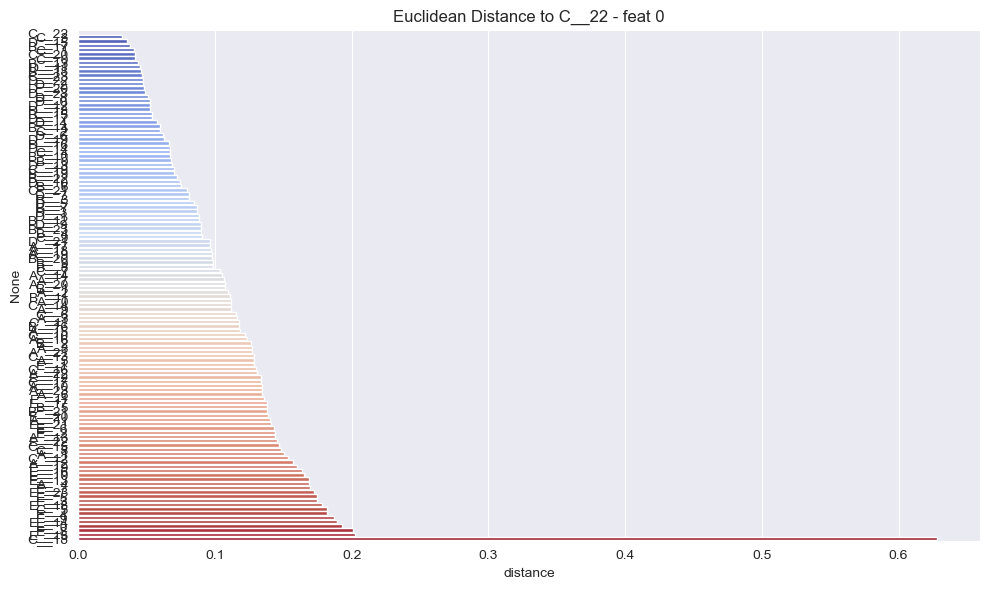

In [69]:
target_label = 22

# ---- 3. Distance comparison ----
for feat in all_series['feat'].unique():
    df_feat = all_series[all_series['feat'] == feat].drop(columns='feat')

    # Scale features
    features_only = df_feat.drop(columns=['client', 'label'], errors='ignore')
    scaler = MinMaxScaler()
    scaled = scaler.fit_transform(features_only)

    # Rebuild scaled DataFrame with preserved metadata
    df_scaled = pd.DataFrame(scaled, columns=features_only.columns, index=df_feat.index)
    df_scaled['client'] = df_feat['client'].values
    df_scaled['label'] = df_feat['label'].values
    df_scaled['key'] = df_scaled.apply(lambda row: f"{row['client']}__{row['label']}", axis=1)

    # Now safe to build vector dict
    vectors = {
        row['key']: row.drop(labels=[col for col in ['client', 'label', 'key'] if col in row])
        .values.reshape(1, -1)
        for idx, row in df_scaled.iterrows()
    }


    target_key = f"{target_client}__{target_label}"
    if target_key not in vectors:
        print(f"⚠️ Target {target_key} not found in this feature set.")
        continue

    target_vector = vectors[target_key]

    # Compute distances
    distance_results = {
        key: cosine_distances(target_vector, vec)[0][0]
        for key, vec in vectors.items()
    }

    # Plot results
    dist_df = pd.DataFrame.from_dict(distance_results, orient='index', columns=['distance'])
    dist_df = dist_df.sort_values('distance', ascending=True)

    plt.figure(figsize=(10, 6))
    sns.barplot(x=dist_df['distance'], y=dist_df.index, palette='coolwarm')
    plt.axvline(0, color='gray', linestyle='--')
    plt.title(f"Euclidean Distance to {target_key} - feat {feat}")
    plt.tight_layout()
    plt.show()


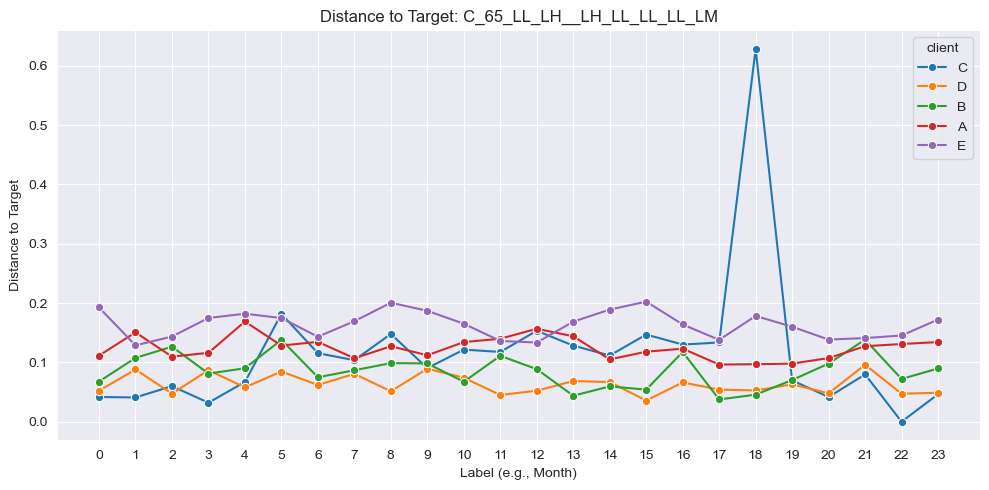

In [70]:
qwe = dist_df.copy().reset_index()
qwe[['client', 'label']] = qwe['index'].str.split('__', expand = True)
qwe['label'] = qwe['label'].astype(int)

plt.figure(figsize=(10, 5))
sns.lineplot(data=qwe, x='label', y='distance', hue='client', marker='o')

plt.title(f"Distance to Target: {case}")
plt.xlabel("Label (e.g., Month)")
plt.ylabel("Distance to Target")
plt.xticks(ticks=sorted(qwe['label'].unique()))
plt.grid(True)
plt.tight_layout()
plt.show()